<a href="https://colab.research.google.com/github/Roshrol/Rpg-Class/blob/main/report.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **RPG Classification**

**Team Members:** Edy Cruz and Layla Robledo  
**GitHub Repository:** https://github.com/Roshrol/Rpg-Class

## Abstract

Our project builds a machine learning model that predicts an RPG character's class based on their stat and skill distribution. We use character attributes such as Strength, Intelligence, Speed, and skills such as Blade, Alchemy, and Sneak as predictors, and the character's RPG class as the target label. We trained a multiclass logistic regression model using cross-entropy loss and evaluated it with training accuracy, test accuracy, and loss. Since there are 21 possible classes, random guessing would only achieve about 5% accuracy, so our goal was to reach around 40–50% accuracy. Our final model reached around 40% test accuracy, meeting our baseline goal.

## Introduction

Role-playing games often ask players to choose a class before they fully understand how different stats and skills affect gameplay. This can be intimidating for new players. Our project addresses this problem by predicting a character's class from their stat distribution. A model like this could eventually help beginners choose a class based on the type of character they want to play.

Previous work has explored similar problems in gaming and machine learning. Joe Macinnes used machine learning and natural language processing to predict Dungeons & Dragons character information from backstories (Macinnes). Jolanta Sliwa explored predictive machine learning in RPG design to study character strength, performance, difficulty, and balance (Sliwa). Louis Khrisna Putera Suryapranata studied personality trait prediction based on game character design using machine learning (Suryapranata). These projects relate to ours because they all use character information to predict or evaluate game-related categories.

## Values Statement

The main users of this project would be beginner RPG players who may feel overwhelmed by character creation. A tool based on this model could help players understand what class best matches the stats and skills they are interested in using.

This technology could benefit new players by making RPGs more accessible and less intimidating. It could also benefit game designers who want to create recommendation systems or beginner-friendly character generators.

When she was younger and new to RPG games, Layla personally was invited to play DnD (Dungeons and Dragons) for the first time, she was intimidated by the character creation aspect and it deterred her from continuing to play. We believe for those who are indecisive and new to the Role-playing game world this might be a beginner friendly way to help them with character creation. We believe this would make the gaming industry more friendly and equitable for those with little prior knowledge on character types, making character creation more accessible.

One possible harm is that the model could oversimplify character creation. Some players enjoy unusual or hybrid builds, and the model might misclassify those characters because they do not follow typical class patterns. For example, an Elf character would most likely have archery attributes however, if a player likes the character design of the elf but the attributes of a mage who has a high magic skill set. Their character would be an outlier and confuse our model. This could make players feel like there is only one “correct” way to build a character.


## Data

Our dataset comes from elderstats.com, where uploaded RPG character information is publicly available. The data was scraped using Python and Playwright. After cleaning, the dataset contains around 280 characters.

Each row represents one character. The target variable is the character's class. The features are 8 main stats, such as Strength, Intelligence, Willpower, Agility, Speed, Endurance, Personality, and Luck, plus 21 skills, such as Blade, Alchemy, Sneak, Restoration, and Marksman.

We removed custom classes because our goal was to focus on premade beginner-friendly classes. We also removed invalid rows with impossible values, such as 0 or 255 in certain stat columns.

In [57]:
!rm -rf /content/Rpg-Class
!git clone https://github.com/Roshrol/Rpg-Class /content/Rpg-Class

import sys
sys.path.append("/content/Rpg-Class/src")
from Final_Project import *

Cloning into '/content/Rpg-Class'...
remote: Enumerating objects: 164, done.
remote: Counting objects: 100% (12/12), done.
remote: Compressing objects: 100% (12/12), done.
remote: Total 164 (delta 5), reused 0 (delta 0), pack-reused 152 (from 1)
Receiving objects: 100% (164/164), 233.22 KiB | 6.14 MiB/s, done.
Resolving deltas: 100% (83/83), done.


In [58]:
import pandas as pd
import numpy as np
import torch
import pickle
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier

from Final_Project import (
    DataPrepPipeline,
    RPG_Model,
    GradientDescentOptimizer,
    cross_entropy_loss,
    accuracy,
)

In [59]:
url = "https://raw.githubusercontent.com/Roshrol/Rpg-Class/refs/heads/main/data/oblivion_characters.csv"
train = pd.read_csv(url)

print("Number of rows:", train.shape[0])
print("Number of columns:", train.shape[1])

train.head()

Number of rows: 283
Number of columns: 31


,url,class,Armorer,Athletics,Blade,Block,Blunt,Hand to Hand,Heavy Armor,Alchemy,...,Sneak,Speechcraft,Strength,Intelligence,Willpower,Agility,Speed,Endurance,Personality,Luck
0,https://www.elderstats.com/character/8,Thief,100.0,84.0,102.0,50.0,25.0,53.0,100.0,20.0,...,102.0,80.0,100,75,88,100,100,90,90,61
1,https://www.elderstats.com/character/22,Warrior,77.0,43.0,59.0,48.0,32.0,35.0,100.0,100.0,...,14.0,19.0,100,37,41,51,44,100,34,51
2,https://www.elderstats.com/character/31,Rogue,34.0,0.0,30.0,29.0,0.0,0.0,0.0,0.0,...,54.0,0.0,56,40,40,79,73,53,52,60
3,https://www.elderstats.com/character/38,Battlemage,22.0,40.0,100.0,19.0,16.0,5.0,9.0,41.0,...,89.0,11.0,102,102,100,70,90,58,82,51
4,https://www.elderstats.com/character/39,Warrior,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,100,42,100,63,72,58,72,49


We created a plot to showcase how certain classes prioritize different stats. We cose intellegence and strength in particular due to them being what makes the bulk of their damage and generally a stats that most people would end up investing in. Our dataset consists of around 280 characters. In particular it seems that mages make up around 17% of our dataset and with 21 classes it can create some bias in our overall distribution of classes. If we could extract a larger dataset then we could likely have an easier time getting far more accurate metrics.

From our visualzation quite a few of the hybrid classes such as spellsword tend leans towards a balanced split of the two. This aligns with the game’s mechanics, where characters are not restricted from using both weapons and magic simultaneously. As a result, there is often no strong penalty for investing in Strength even for magic-oriented classes. This means that even a few mages go for a couple of point in strength, just not to a larger degree than some other classes.

Rhe plot also shows that many classes cluster around similar Strength values of around 100. Inversely, Intellegence seems to differ significantly. This seems to suggests that based on our dataset, Intelligence is a stronger distinguishing feature between classes than Strength.

<Figure size 800x600 with 0 Axes>

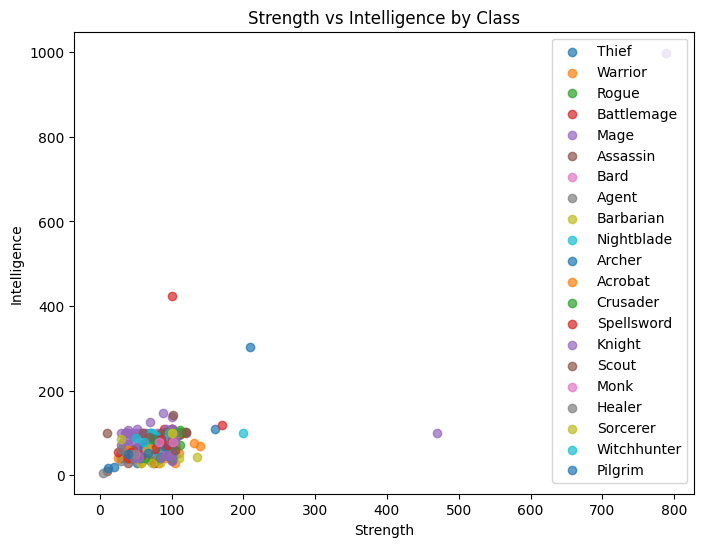

In [60]:
y_df = train["class"]

# Created a plot that shows strength vs intellegence by class
plt.figure(figsize=(8,6))
classes = y_df.unique()

fig, ax = plt.subplots(figsize=(8,6))
# Give me only the rows where the class equals i
for i in classes:
    subset = train[train["class"] == i]

    ax.scatter(
        subset["Strength"],
        subset["Intelligence"],
        label=i,
        alpha=0.7
        )

ax.set_title("Strength vs Intelligence by Class")
ax.set_xlabel("Strength")
ax.set_ylabel("Intelligence")

ax.legend()

plt.show()

## Approach

We used the character's stats and skills as predictors and the character's class as the target. Since the target has more than two possible classes, this is a multiclass classification problem.

Our model is multiclass logistic regression. The model takes the normalized feature values and outputs one score for each possible class. We trained the model using cross-entropy loss because it is appropriate for multiclass classification.

We split the data into an 80% training set and a 20% test set. The data preparation pipeline learned the mean and standard deviation only from the training set, then used those same values to normalize both the training and test sets.

The dataset occasionally contains 0 when skills are unused or not copied properly. Thus it removes rows where all skills are 0. This will likely introduce some bias as if skills aren't taken into account for some of the dataset it would scew towards stats which can be a little less informative than attributes.

In [61]:
train = train.dropna()
train = train[
        (train.select_dtypes(include=[np.number]) < 300).all(axis=1)
    ]

# remove rows where all skills are 0
skill_cols = [
        "Armorer", "Athletics", "Blade", "Block", "Blunt",
        "Hand to Hand", "Heavy Armor", "Alchemy", "Alteration",
        "Conjuration", "Destruction", "Illusion", "Mysticism",
        "Restoration", "Acrobatics", "Light Armor", "Marksman",
        "Mercantile", "Security", "Sneak", "Speechcraft"
    ]

train = train[(train[skill_cols].sum(axis=1) > 0)]
# Randomly sample 80% of the rows to be the training set
train_ix = train.sample(frac=0.8, random_state=42).index
test_ix = train.drop(train_ix).index
# separate the features and targets
X_df = train.drop(columns=["class", "url"])
y_df = train["class"]

pipeline = DataPrepPipeline()
pipeline.fit(X_df.loc[train_ix], y_df.loc[train_ix])

X_train = pipeline.transform(X_df.loc[train_ix])
y_train = pipeline.transform_labels(y_df.loc[train_ix])
# Transform test features using the same stat from training set
X_test = pipeline.transform(X_df.loc[test_ix])
y_test = pipeline.transform_labels(y_df.loc[test_ix])

print("Training examples:", X_train.shape[0])
print("Testing examples:", X_test.shape[0])
print("Number of features:", X_train.shape[1])

Training examples: 197
Testing examples: 49
Number of features: 29


In [62]:
num_classes = len(set(y_df))

torch.manual_seed(1)
np.random.seed(1)

model = RPG_Model(X_train.shape[1], num_classes)
opt = GradientDescentOptimizer(model, lr=0.01)

losses = []
train_accs = []
reg_losses = []

for epoch in range(30000):
    q = model.forward(X_train)
    loss = cross_entropy_loss(q, y_train)

    loss.backward()
    opt.step()

    losses.append(loss.item())
    train_accs.append(loss.item())
    reg_losses.append(loss.item())

    if epoch % 1000 == 0:
        train_acc = accuracy(model, X_train, y_train).item()
        test_acc = accuracy(model, X_test, y_test).item()
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}, Train Acc: {train_acc:.4f}, Test Acc: {test_acc:.4f}")

Epoch 0, Loss: 10.2728, Train Acc: 0.0406, Test Acc: 0.0612
Epoch 1000, Loss: 3.5017, Train Acc: 0.2995, Test Acc: 0.3469
Epoch 2000, Loss: 2.4940, Train Acc: 0.3959, Test Acc: 0.3061
Epoch 3000, Loss: 2.0147, Train Acc: 0.4975, Test Acc: 0.2449
Epoch 4000, Loss: 1.7196, Train Acc: 0.5482, Test Acc: 0.2857
Epoch 5000, Loss: 1.5034, Train Acc: 0.5939, Test Acc: 0.3061
Epoch 6000, Loss: 1.3363, Train Acc: 0.6345, Test Acc: 0.3265
Epoch 7000, Loss: 1.2024, Train Acc: 0.6853, Test Acc: 0.3061
Epoch 8000, Loss: 1.0925, Train Acc: 0.7005, Test Acc: 0.3061
Epoch 9000, Loss: 1.0041, Train Acc: 0.7259, Test Acc: 0.3061
Epoch 10000, Loss: 0.9332, Train Acc: 0.7513, Test Acc: 0.3265
Epoch 11000, Loss: 0.8743, Train Acc: 0.7563, Test Acc: 0.3265
Epoch 12000, Loss: 0.8243, Train Acc: 0.7614, Test Acc: 0.3265
Epoch 13000, Loss: 0.7812, Train Acc: 0.7665, Test Acc: 0.3469
Epoch 14000, Loss: 0.7434, Train Acc: 0.7766, Test Acc: 0.3469
Epoch 15000, Loss: 0.7100, Train Acc: 0.7868, Test Acc: 0.3469
Epoc

## Results

The model successfully learned patterns between character stats, skills, and RPG classes. We evaluated the model using cross-entropy loss, training accuracy, and test accuracy. Since there are 21 possible classes, random guessing would only be expected to achieve about 5% accuracy.

Our training accuracy ended up being around 90% and loss was near 0 which we found to be quite unusual. We can also see that our training loss seemd to flatted around 25000 epochs. This when contrasted with out test accuracy which was around 40% and about a loss of around 3, created a massive disparity. This likely meant that there potential was overfitting. In an attempt to fix this we tried adding regularization, firstly with it being 0.01, 0.001 and 0.005. We ended up settling on 0.001 as it gave us the most consistant accuracy.

The results of adding regularization seemed to be quite disappointing, it didn't seem to make our model more accurate and if it did it was by a very miniscule amount. This led us to a couple of potential conclusions, firstly the bottleneck might be our small dataset which in total only consists of around 280 samples. In addition perhaps our model is too simple and thus can only learn simple patterns. Regardless of the outcome we did end up generally reaching our achieved result. Our test accuracy was around 40%, which met our original baseline goal of 40–50%.

We decided to compare our multiclass logistic regression model against another machine learning approach. We ended up deciding on training and comparing a decision tree model. Unlike our logistic regression model, the decision tree one creates nonlinear decision boundaries with its branches and hierarchical feature. Since we use both stats and features to find what type between 21 different options the decision tree would find the most likely combinations. However as we can see in both the output and the graph, the decision tree achieved different and lower accuracy than the logistic regression model. We have a smaller dataset and because of this we found that the strict hierarcy system of the tree model is less likely to preform as well as the more general classification we get from the logistic regression model we decided on.

We added a confusion matrix which shows what values along the diagonal axis represent correct predictions made. Off of the diagonal shows misclassifications between the RPG character predictions.
With these results we can see that some classes were more accurately predicted than others and others because of the overlap in charcter feature were much more likely to get confused.

Train loss: 0.45353689789772034
Train accuracy: 0.8883248567581177
Test accuracy:  0.40816327929496765
Test Loss: 3.120215892791748
Decision tree train acc: 0.6040609137055838
Decision tree test acc: 0.22448979591836735


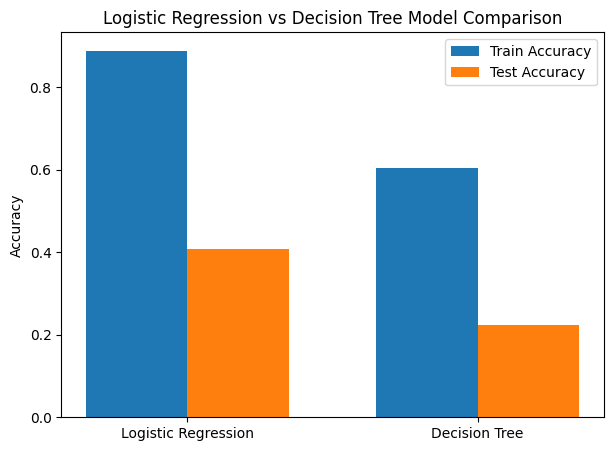

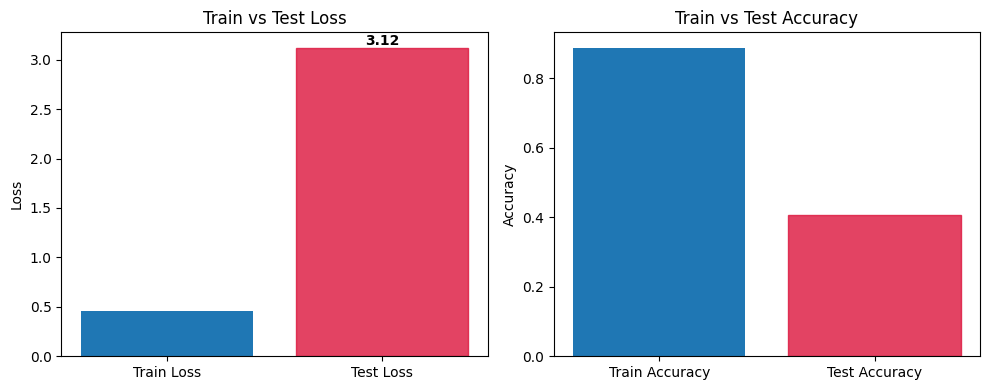

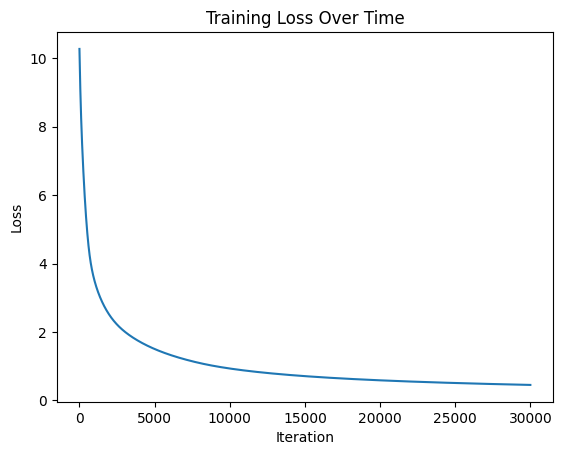

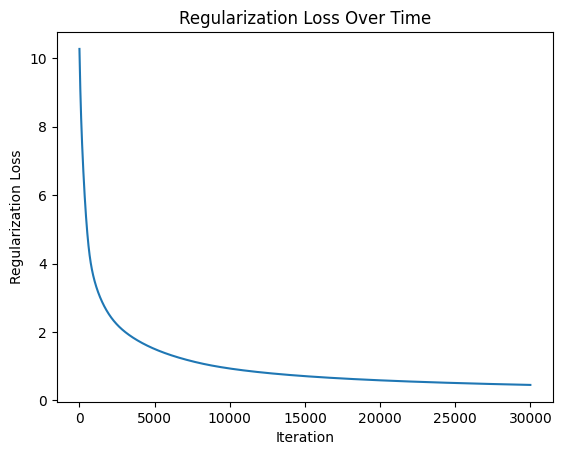

Confusion Matrix:
tensor([[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 5, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
        [1, 1, 0, 4, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0],
        [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0],
        [0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 1, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 

In [63]:
    import matplotlib.pyplot as plt

    train_loss = cross_entropy_loss(q, y_train).item()
    #training accuracy
    acc = accuracy(model, X_train, y_train).item()

    #test accuracy
    test_acc  = accuracy(model, X_test,  y_test).item()
    test_loss = cross_entropy_loss(model.forward(X_test), y_test).item()

    print("Train loss:", train_loss)
    print("Train accuracy:", acc)
    print("Test accuracy: ", test_acc)
    print("Test Loss:", test_loss)

    tree = DecisionTreeClassifier(
        max_depth = 5,
        random_state = 42 #21+21 skills and attributes
    )

    tree.fit(
        X_train.numpy(),
        y_train.numpy()
    )

    tree_train_acc = tree.score(
        X_train.numpy(),
        y_train.numpy()
    )

    tree_test_acc = tree.score(
        X_test.numpy(),
        y_test.numpy()
    )

    print("Decision tree train acc:", tree_train_acc)
    print("Decision tree test acc:", tree_test_acc)

    models = ["Logistic Regression", "Decision Tree"]

    train_scores = [acc, tree_train_acc]
    test_scores = [test_acc, tree_test_acc]

    x = np.arange(len(models))
    width = 0.35

    fig, ax = plt.subplots(figsize=(7,5))

    ax.bar(x - width/2, train_scores, width, label = "Train Accuracy")
    ax.bar(x + width/2, test_scores, width, label = "Test Accuracy")

    ax.set_title("Logistic Regression vs Decision Tree Model Comparison")
    ax.set_ylabel("Accuracy")
    ax.set_xticks(x)
    ax.set_xticklabels(models)
    ax.legend()

    plt.show()

    ig, ax = plt.subplots(1, 2, figsize=(10, 4))

    #Loss comparison
    ax[0].set_title("Train vs Test Loss")
    ax[0].set_ylabel("Loss")

    # Accuracy comparison
    acc_bars = ax[1].bar(
        ["Train Accuracy", "Test Accuracy"],[acc, test_acc])

    ax[1].set_title("Train vs Test Accuracy")
    ax[1].set_ylabel("Accuracy")

    # highlight test accuracy bar
    acc_bars[1].set_color("crimson")
    acc_bars[1].set_alpha(0.8)

    bars = ax[0].bar(["Train Loss", "Test Loss"],[train_loss, test_loss])

    # highlight test loss bar
    bars[1].set_color("crimson")
    bars[1].set_alpha(0.8)

    ax[0].text(1, test_loss, f"{test_loss:.2f}", ha="center", va="bottom", fontsize=10, fontweight="bold")

    plt.tight_layout()
    plt.show()

    # Loss
    fig, ax = plt.subplots()

    ax.plot(losses)
    ax.set_title("Training Loss Over Time")
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Loss")

    plt.show()

    fig, ax = plt.subplots()

    ax.plot(reg_losses)
    ax.set_title("Regularization Loss Over Time")
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Regularization Loss")

    plt.show()

    #confusion matrix
    predictions = model.predict(X_test)

    num_classes = len(classes)

    cm = torch.zeros((num_classes, num_classes), dtype=torch.int32)

    for i in range(num_classes):
      for j in range(num_classes):
        cm[i, j] = ((y_test == i) & (predictions == j)).sum().item()

    print("Confusion Matrix:")
    print(cm)
    print("Test Accuracy:", (cm.diag().sum() / cm.sum()).item())

## Concluding Discussion

Our project worked because the model was able to predict RPG classes much better than random guessing. With 21 possible classes, random guessing would be around 5%, while our model reached around 40% test accuracy. This means the model learned meaningful patterns between stats, skills, and classes.

We met our original goal of reaching around 40–50% accuracy. However, the training accuracy was higher than the test accuracy, which suggests some mild overfitting. This makes sense because our dataset is fairly small and some RPG classes are hybrids that share similar stats and skills.

If we had more time, we would try adding more features such as race and level. We could also experiment with more models and feature engineering to better handle hybrid classes.

## Group Contributions

Edy primarily worked on collecting and scraping the dataset. He used Python and Playwright to gather RPG character information and helped clean invalid characters from the dataset. He added in regularization to the model. He worked on plotting the data, especially in regards to loss, accuracy and the effect regularization had on the model. He also helped manage and organize the GitHub repository.

Edy created a couple of plots to showcase the results of our model. Comparisons between training and testing loss, training and testing accuracy, loss over time and regularization loss over time.

Layla worked on the data preparation pipeline, including selecting features, normalizing the dataset, transforming labels, and setting up the training process. She also worked on the model training code, accuracy reporting, and organizing the final report notebook.

Layla also worked on comparing our chosen logistic regression classification model to a model learned outside of class but briefly mentioned, the decision tree model. She created a graph and explained the results showing the accuracy difference achieved. She also created the confision matrix. Which is very helpful considering how many classes there are as well as the overlap between skills and attributes some character types may have.

Both group members experimented with learning rate, number of epochs, and model performance. Both also contributed to the final writing and discussion of the project results.

## Work Cited

* Macinnes, Joe. “Predicting DND Character Attributes with Machine Learning.”

* Sliwa, Jolanta. “Application of Predictive Machine Learning in Pen & Paper RPG Design.”

* Suryapranata, Louis Khrisna Putera. “Personality Trait Prediction Based on Game Character Design.”